In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/uciml/sms-spam-collection-dataset/spam.csv


# SMS Spam Classification Using Machine Learning

## Objective

This experiment explores how Natural Language Processing (NLP) and Machine Learning can be used to classify SMS messages as **Ham (legitimate)** or **Spam (suspicious/unwanted)**.

The experiment is conducted as a preliminary study for understanding text-based analysis that may later be incorporated as one component of an AI-based financial security system.

## Dataset

The **SMS Spam Collection Dataset** contains labelled SMS messages belonging to two classes:

- **Ham:** Legitimate messages
- **Spam:** Unwanted or suspicious messages

The dataset is used here for studying **text classification and NLP techniques**. It is not a financial transaction-risk dataset.

## Main Workflow

1. Dataset loading and inspection
2. Data cleaning and preprocessing
3. Class distribution analysis
4. Train-test split
5. TF-IDF feature extraction
6. Machine Learning model training
7. Handling class imbalance
8. Model evaluation using precision, recall, F1-score and ROC-AUC
9. Comparison of model performance

In [2]:
pip install pandas scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [4]:
print(os.listdir("/kaggle/input/datasets"))

['uciml']


In [5]:
print(os.listdir("/kaggle/input/datasets/uciml"))

['sms-spam-collection-dataset']


In [6]:
print(os.listdir("/kaggle/input/datasets/uciml/sms-spam-collection-dataset"))

['spam.csv']


## 1. Dataset Loading and Inspection

The SMS Spam Collection dataset was loaded using Pandas. The original dataset contains SMS messages labelled as either **ham** or **spam**.

The dataset was first inspected to understand:
- The available columns
- Number of records
- Class distribution
- Missing values
- Duplicate messages

The original dataset contains two useful columns:
- `v1` → SMS label
- `v2` → SMS message

The unnecessary columns were removed, and the remaining columns were renamed to `label` and `message` for easier processing.

In [7]:
#loading the dataset

import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/uciml/sms-spam-collection-dataset/spam.csv",
    encoding="latin-1"
)

print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [8]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [9]:
df = df[['v1', 'v2']]

print(df.head())

#Keeping only the first and second columns 

     v1                                                 v2
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [10]:
#Renaming the columns

df.columns = ['label', 'message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [11]:
print(df.shape)

(5572, 2)


In [12]:
print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [13]:
print(df['label'].value_counts(normalize=True) * 100)

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [14]:
print(df[df['label'] == 'ham']['message'].head(5).to_string(index=False))

Go until jurong point, crazy.. Available only i...
                     Ok lar... Joking wif u oni...
 U dun say so early hor... U c already then say...
Nah I don't think he goes to usf, he lives arou...
Even my brother is not like to speak with me. T...


In [15]:
print(df[df['label'] == 'spam']['message'].head(5).to_string(index=False))

Free entry in 2 a wkly comp to win FA Cup final...
FreeMsg Hey there darling it's been 3 week's no...
WINNER!! As a valued network customer you have ...
Had your mobile 11 months or more? U R entitled...
SIX chances to win CASH! From 100 to 20,000 pou...


In [16]:
#checking for missing values

print(df.isnull().sum())

label      0
message    0
dtype: int64


In [17]:
#checking for duplicate values

print(df.duplicated().sum())

403


In [18]:
#Remove duplicate rows

df = df.drop_duplicates()

print(df.shape)

(5169, 2)


In [19]:
print(df['label'].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


In [20]:
print(df['label'].value_counts(normalize=True) * 100)

label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


## 2. Data Cleaning and Preprocessing

The SMS messages were cleaned and preprocessed before applying machine learning.

The following preprocessing steps were performed:

1. **Lowercasing** – Converted all messages to lowercase.
2. **Punctuation removal** – Removed punctuation characters.
3. **Stopword removal** – Removed common English words that provide limited information for classification.
4. **Whitespace normalization** – Removed unnecessary spaces and standardized spacing.
5. **Empty message removal** – Removed messages that became empty after preprocessing.

These steps help reduce unnecessary variation in the text and prepare the messages for numerical feature extraction using TF-IDF.

In [21]:
#Convert all messages to lowercase

df['message'] = df['message'].str.lower()

In [22]:
print(df['message'].head())

0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
3    u dun say so early hor... u c already then say...
4    nah i don't think he goes to usf, he lives aro...
Name: message, dtype: object


In [23]:
#remove punctuations

import string

df['message'] = df['message'].str.translate(
    str.maketrans('', '', string.punctuation)
)

In [24]:
print(df['message'].head())

0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in 2 a wkly comp to win fa cup fina...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: message, dtype: object


In [25]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
#remove the common English stopwords from each SMS.

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['message'] = df['message'].apply(
    lambda text: ' '.join(
        word for word in text.split()
        if word not in stop_words
    )
)

In [27]:
print(df['message'].head())

0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry 2 wkly comp win fa cup final tkts 2...
3                  u dun say early hor u c already say
4          nah dont think goes usf lives around though
Name: message, dtype: object


In [28]:
#Removed extra whitespace

df['message'] = df['message'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [29]:
print(df['message'].head())

0    go jurong point crazy available bugis n great ...
1                              ok lar joking wif u oni
2    free entry 2 wkly comp win fa cup final tkts 2...
3                  u dun say early hor u c already say
4          nah dont think goes usf lives around though
Name: message, dtype: object


In [30]:
print("Missing messages:", df['message'].isnull().sum())
print("Empty messages:", (df['message'].str.strip() == '').sum())

Missing messages: 0
Empty messages: 5


In [31]:
#Remove the 5 empty messages

df = df[df['message'].str.strip() != '']

In [32]:
print(df.shape)

(5164, 2)


In [33]:
print(df['label'].value_counts())

label
ham     4511
spam     653
Name: count, dtype: int64


In [34]:
print(df['label'].value_counts(normalize=True) * 100)

label
ham     87.354764
spam    12.645236
Name: proportion, dtype: float64


## 3. Class Distribution After Cleaning

After removing duplicate and empty messages, the dataset contains **5,164 SMS messages**.

The class distribution is:

- **Ham:** 4,511 messages (87.35%)
- **Spam:** 653 messages (12.65%)

The dataset is therefore **imbalanced**, with ham messages forming the majority class.

This imbalance was retained because it represents the original distribution of the dataset. Instead of artificially making the classes equal, class proportions were preserved during the train-test split using stratification.

The effect of class imbalance was further addressed during model training and evaluation using techniques such as `class_weight='balanced'`, precision, recall, F1-score, and confusion matrix.

## 4. Train-Test Split

The cleaned dataset was divided into training and testing sets using an **80:20 split**.

- **Training set:** 4,131 messages
- **Testing set:** 1,033 messages

The parameter `stratify=y` was used to preserve the original proportion of ham and spam messages in both the training and testing sets.

The `random_state=42` parameter ensures that the same split can be reproduced when the code is run again.

In [35]:
#Train/Test Split

# stratify=y keeps the same class (fraud/legitimate) proportion in both train and test sets

from sklearn.model_selection import train_test_split

X = df['message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4131
Testing samples: 1033


## 5. TF-IDF Feature Extraction

Since machine learning models cannot directly process raw text, the SMS messages were converted into numerical features using **TF-IDF (Term Frequency-Inverse Document Frequency)**.

TF-IDF gives higher importance to words that are distinctive to particular messages and lower importance to words that occur frequently across many messages.

The TF-IDF vectorizer was fitted only on the training data to avoid **data leakage**. The same learned vocabulary and statistics were then used to transform the test data.

After transformation:

- **Training data:** 4,131 messages × 8,202 features
- **Testing data:** 1,033 messages × 8,202 features

The 8,202 features represent the vocabulary learned from the training messages.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer()

In [38]:
# Learn TF-IDF information from the training data and convert training messages into numerical features

X_train_tfidf = tfidf.fit_transform(X_train)

In [39]:
# Convert the test SMS messages into TF-IDF numerical features using the vocabulary/statistics already learned from the training data

X_test_tfidf = tfidf.transform(X_test)

In [40]:
# Check the number of SMS messages and TF-IDF features

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4131, 8202)
Testing TF-IDF shape: (1033, 8202)


## 6. Logistic Regression

Logistic Regression was used as the first baseline classification model.

The model was trained on the TF-IDF features to classify each SMS message as either **ham** or **spam**.

The initial model achieved:

- **Accuracy:** 95.26%
- **Spam Precision:** 95%
- **Spam Recall:** 66%
- **Spam F1-score:** 78%

The results show that the model had high precision for spam but missed some actual spam messages, resulting in a relatively lower spam recall.

In [41]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression()

# Train the model using the TF-IDF training data and their labels
model.fit(X_train_tfidf, y_train)


#The model learns patterns in the TF-IDF features that help distinguish ham messages from spam messages.

LogisticRegression()

In [42]:
# Predict the labels for the test messages
y_pred = model.predict(X_test_tfidf)

# Display the first 10 predictions
print(y_pred[:10])

['spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [43]:
from sklearn.metrics import accuracy_score

# Calculate how many test messages were classified correctly
accuracy = accuracy_score(y_test, y_pred)

# Display the accuracy
print("Accuracy:", accuracy)

Accuracy: 0.952565343659245


In [44]:
from sklearn.metrics import classification_report

# Generate precision, recall, and F1-score for ham and spam
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.95      0.99      0.97       902
        spam       0.95      0.66      0.78       131

    accuracy                           0.95      1033
   macro avg       0.95      0.83      0.88      1033
weighted avg       0.95      0.95      0.95      1033



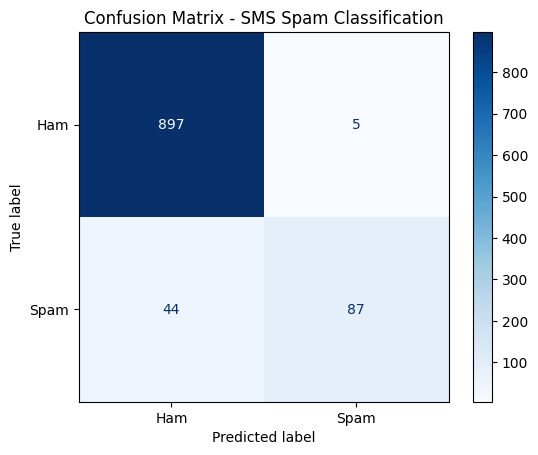

In [45]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create and display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Ham', 'Spam'],
    cmap='Blues'
)

# Add a title to the confusion matrix
plt.title("Confusion Matrix - SMS Spam Classification")

# Display the plot
plt.show()

In [46]:
# Store the Logistic Regression results as our baseline
baseline_accuracy = accuracy
baseline_spam_precision = 0.95
baseline_spam_recall = 0.66
baseline_spam_f1 = 0.78

# Display the baseline results
print("Logistic Regression Baseline")
print("Accuracy:", baseline_accuracy)
print("Spam Precision:", baseline_spam_precision)
print("Spam Recall:", baseline_spam_recall)
print("Spam F1-score:", baseline_spam_f1)

Logistic Regression Baseline
Accuracy: 0.952565343659245
Spam Precision: 0.95
Spam Recall: 0.66
Spam F1-score: 0.78


## 7. Multinomial Naive Bayes

Multinomial Naive Bayes was used as another classification model for comparison.

It is commonly used for text classification because it works well with numerical representations of word frequencies and TF-IDF features.

The model achieved:

- **Accuracy:** 97%
- **Spam Precision:** 100%
- **Spam Recall:** 75%
- **Spam F1-score:** 86%

Compared with the initial Logistic Regression model, Naive Bayes improved spam recall while maintaining high precision.

In [47]:
from sklearn.naive_bayes import MultinomialNB

# Create the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model using the TF-IDF training data
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [48]:
# Predict the labels for the test messages using Naive Bayes
y_pred_nb = nb_model.predict(X_test_tfidf)

# Display the first 10 predictions
print(y_pred_nb[:10])

['spam' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [49]:
from sklearn.metrics import classification_report

# Evaluate the Naive Bayes predictions
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       902
        spam       1.00      0.75      0.86       131

    accuracy                           0.97      1033
   macro avg       0.98      0.87      0.92      1033
weighted avg       0.97      0.97      0.97      1033



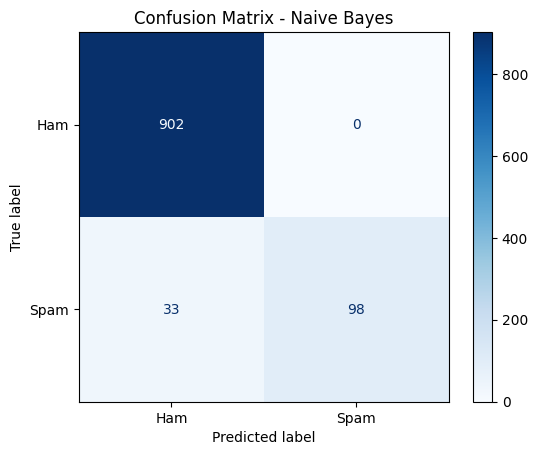

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create and display the Naive Bayes confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels=['Ham', 'Spam'],
    cmap='Blues'
)

# Add a title
plt.title("Confusion Matrix - Naive Bayes")

# Display the plot
plt.show()

## 8. Balanced Logistic Regression

Since the dataset is imbalanced, Logistic Regression was also trained using `class_weight='balanced'`.

This automatically gives greater importance to the minority **spam** class during training. It does not create new messages or change the dataset size.

The balanced model achieved:

- **Accuracy:** 97%
- **Spam Precision:** 86%
- **Spam Recall:** 91%
- **Spam F1-score:** 88%

Compared with the initial Logistic Regression model, spam recall increased from **66% to 91%**. This means the balanced model detected a larger proportion of the actual spam messages, although its spam precision decreased from **95% to 86%**.

In [51]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression with higher importance given to the minority class
balanced_model = LogisticRegression(class_weight='balanced')

# Train the balanced model using the TF-IDF training data
balanced_model.fit(X_train_tfidf, y_train)

#class_weight='balanced' automatically gives more weight to the minority spam class during training.

LogisticRegression(class_weight='balanced')

In [52]:
# Predict the labels for the test messages using the balanced model
y_pred_balanced = balanced_model.predict(X_test_tfidf)

# Display the first 10 predictions
print(y_pred_balanced[:10])

['spam' 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


In [53]:
from sklearn.metrics import classification_report

# Evaluate the balanced Logistic Regression predictions
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

         ham       0.99      0.98      0.98       902
        spam       0.86      0.91      0.88       131

    accuracy                           0.97      1033
   macro avg       0.92      0.94      0.93      1033
weighted avg       0.97      0.97      0.97      1033



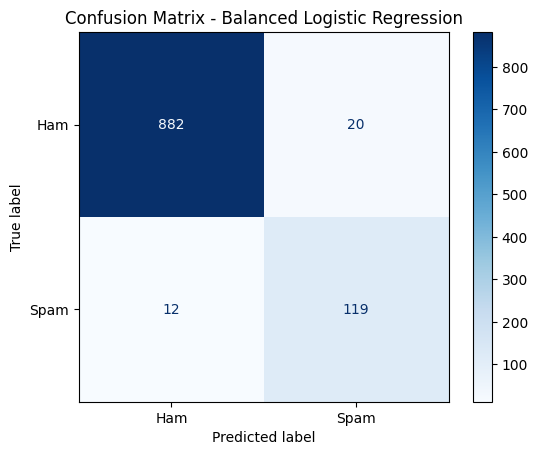

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create and display the confusion matrix for the balanced model
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_balanced,
    display_labels=['Ham', 'Spam'],
    cmap='Blues'
)

# Add a title
plt.title("Confusion Matrix - Balanced Logistic Regression")

# Display the plot
plt.show()

## 9. Model Comparison

The three models were compared using accuracy, spam precision, spam recall, and spam F1-score.

| Model | Accuracy | Spam Precision | Spam Recall | Spam F1-score |
|---|---:|---:|---:|---:|
| Logistic Regression | 95.26% | 95% | 66% | 78% |
| Multinomial Naive Bayes | 97% | 100% | 75% | 86% |
| Balanced Logistic Regression | 97% | 86% | 91% | 88% |

The results show different trade-offs between precision and recall. The balanced Logistic Regression model achieved the highest spam recall among the three models, while Naive Bayes achieved the highest spam precision.

In [55]:
import pandas as pd

# Create a table comparing the three models
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Balanced Logistic Regression'
    ],
    'Accuracy': [
        0.9526,
        0.9700,
        0.9700
    ],
    'Spam Precision': [
        0.95,
        1.00,
        0.86
    ],
    'Spam Recall': [
        0.66,
        0.75,
        0.91
    ],
    'Spam F1-Score': [
        0.78,
        0.86,
        0.88
    ]
})

# Display the comparison table
print(model_results)

                          Model  Accuracy  Spam Precision  Spam Recall  \
0           Logistic Regression    0.9526            0.95         0.66   
1                   Naive Bayes    0.9700            1.00         0.75   
2  Balanced Logistic Regression    0.9700            0.86         0.91   

   Spam F1-Score  
0           0.78  
1           0.86  
2           0.88  


In [56]:
# Get the probability of each test message being spam
y_prob_balanced = balanced_model.predict_proba(X_test_tfidf)[:, 1]

# Display the first 10 spam probabilities
print(y_prob_balanced[:10])

[0.9635465  0.16313187 0.82103174 0.17537579 0.02521626 0.13545917
 0.01210489 0.18412827 0.39039236 0.28101387]


## 10. ROC-AUC Evaluation

ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) was used to evaluate how well the balanced Logistic Regression model distinguishes between ham and spam across different classification thresholds.

The model achieved a **ROC-AUC score of 0.9886 (98.86%)**.

A ROC-AUC value closer to 1 indicates better separation between the two classes. The obtained score indicates that the model was able to distinguish spam from ham very well on the test set.

Unlike `predict()`, which directly produces the predicted class, `predict_proba()` provides the probability of a message belonging to each class. These probabilities were used to calculate the ROC-AUC score.

In [57]:
from sklearn.metrics import roc_auc_score

# Convert the actual labels into binary values: ham = 0, spam = 1
y_test_binary = (y_test == 'spam').astype(int)

# Calculate the ROC-AUC score using the predicted spam probabilities
roc_auc = roc_auc_score(y_test_binary, y_prob_balanced)

# Display the ROC-AUC score
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9885665442358795


## 11. Conclusion

This experiment demonstrated the use of NLP and Machine Learning for SMS text classification.

The main steps included data preprocessing, TF-IDF feature extraction, train-test splitting, classification using multiple ML models, handling class imbalance, and performance evaluation.

The balanced Logistic Regression model achieved a **spam recall of 91%**, **spam F1-score of 88%**, and **ROC-AUC of 98.86%** on the test set.

The experiment provides a practical understanding of how text-based machine learning can identify suspicious messages. However, the SMS Spam Collection dataset is a text-classification dataset and does not contain financial transaction information such as transaction amount, merchant, device, location, or transaction history.

Therefore, this experiment should be considered a **preliminary NLP study** rather than the final financial transaction-risk model for the proposed FinTech security system.